In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
heart_data= pd.read_csv('C:\\Users\\EliteBook\\Desktop\\New folder\\dataset2\\Datasets\\heart_disease_uci.csv')
heart_data.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# to check for number of missing data
print(heart_data.isna().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [4]:
#fill multiple columns with median(why? outlier can affect mean, its save to use median)
heart_data = heart_data.fillna(heart_data[['trestbps', 'chol', 'restecg','exang','oldpeak', 'thalch']].median(numeric_only=True))

In [5]:
# categorical columns are illed with mode
heart_data = heart_data.fillna(heart_data[['restecg', 'fbs', 'exang']].mode().iloc[0])

C:\Users\EliteBook\AppData\Local\Temp\ipykernel_8004\677369451.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_data = heart_data.fillna(heart_data[['restecg', 'fbs', 'exang']].mode().iloc[0])


In [6]:
heart_data=heart_data.drop(columns=['slope','ca','thal'])

In [7]:
heart_data['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [8]:
heart_data['heart_disease'] = np.where(heart_data['num']>0,1,0)

In [12]:
print(heart_data.isna().sum())

id               0
age              0
sex              0
dataset          0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalch           0
exang            0
oldpeak          0
num              0
heart_disease    0
dtype: int64


In [9]:
# put age into different category
# asd=heart_data[heart_data['age']==heart_data['age'].max()]
bins=[20,30,40,50,60,70,80]

labels= ['20-30', '30-40', '40-50', '50-60', '60-70', '70-80']

heart_data['Age_group']=pd.cut(heart_data['age'], bins=bins, labels=labels)




In [10]:
#age prevalence
age_prevalence=heart_data.groupby('Age_group')['heart_disease'].mean()*100


C:\Users\EliteBook\AppData\Local\Temp\ipykernel_8004\4099371229.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_prevalence=heart_data.groupby('Age_group')['heart_disease'].mean()*100


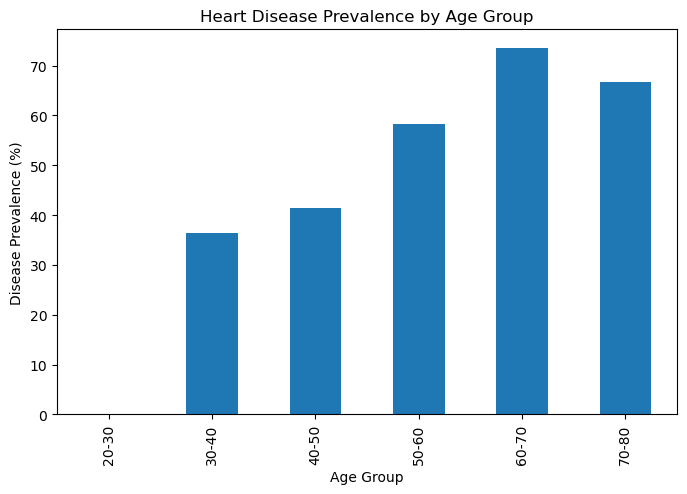

In [11]:
age_prevalence.plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel("Age Group")
plt.ylabel("Disease Prevalence (%)")
plt.title("Heart Disease Prevalence by Age Group")

plt.show()

In [12]:
heart_data['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [13]:
# Male vs Female Risk Differences mapping
heart_data['gender'] = heart_data['sex'].map({
    'Male':1,
    'Female':0
})

In [14]:
heart_data.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num,heart_disease,Age_group,gender
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0,0,60-70,1
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2,1,60-70,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1,1,60-70,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0,0,30-40,1
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0,0,40-50,0


In [33]:
# gender risk calculation
gender_risk= heart_data.groupby('gender')['heart_disease'].mean()*100
gender_risk

gender
0    25.773196
1    63.223140
Name: heart_disease, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

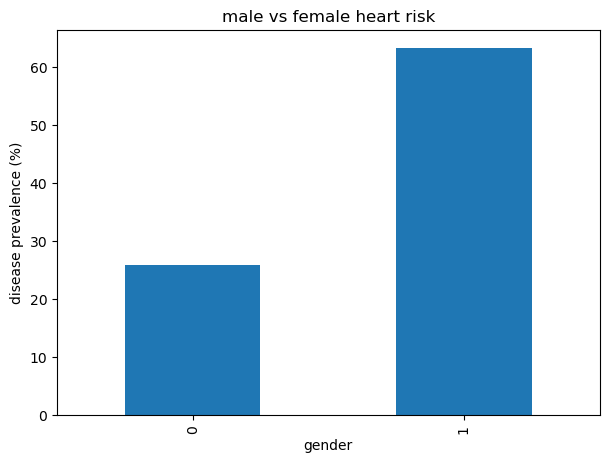

In [35]:
#barchart to visualize gender rrisk
gender_risk.plot(
    kind='bar',
    figsize=(7,5)
)
plt.ylabel('disease prevalence (%)')
plt.title('male vs female heart risk')
plt.show
           

Does disease severity increase with age?

In [42]:
severity=heart_data.groupby('age')['num'].mean()

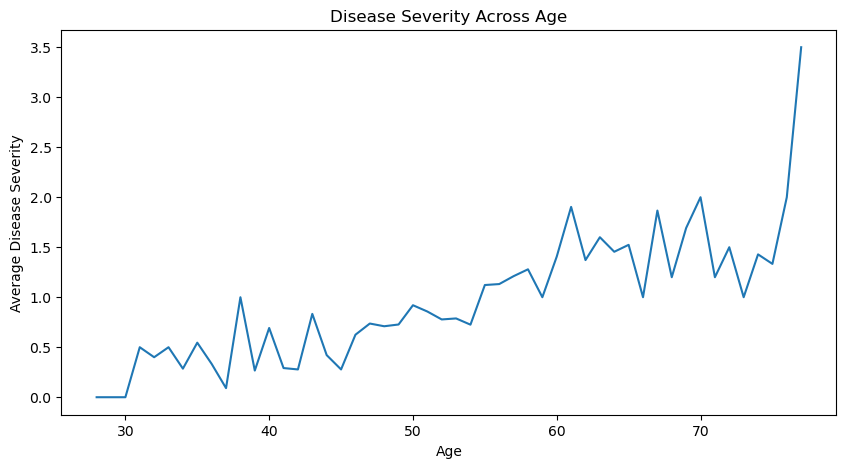

In [43]:
#plot

plt.figure(figsize=(10,5))

plt.plot(
    severity.index,
    severity.values
)
plt.xlabel("Age")
plt.ylabel("Average Disease Severity")
plt.title(
    "Disease Severity Across Age"
)
plt.show()

In [45]:
# Cholesterol vs  hearrt Disease
chol_disease = (
    heart_data.groupby('heart_disease')['chol']
    .mean()
)

print(chol_disease)

heart_disease
0    227.678832
1    177.485265
Name: chol, dtype: float64


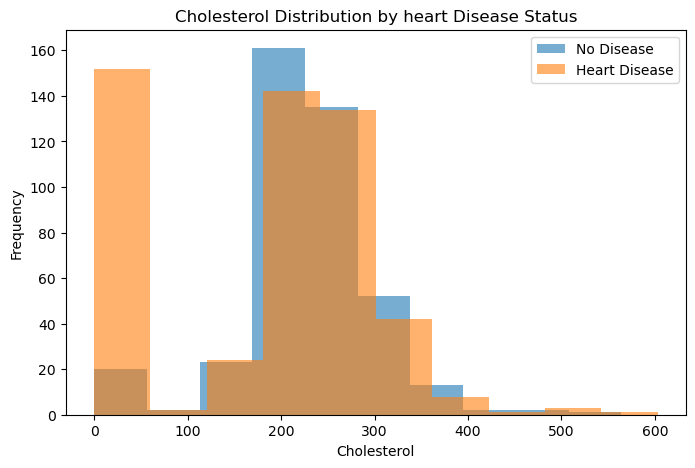

In [47]:
# distribution
plt.figure(figsize=(8,5))

plt.hist(
    heart_data[heart_data['heart_disease']==0]['chol'],
    alpha=0.6,
    label='No Disease'
)

plt.hist(
    heart_data[heart_data['heart_disease']==1]['chol'],
    alpha=0.6,
    label='Heart Disease'
)

plt.xlabel("Cholesterol")

plt.ylabel("Frequency")

plt.title(
    "Cholesterol Distribution by heart Disease Status"
)

plt.legend()

plt.show()

In [48]:
# Blood Pressure vs Heart Disease
bp = (
    heart_data.groupby('heart_disease')['trestbps']
    .mean()
)

print(bp)

heart_disease
0    129.917275
1    133.673870
Name: trestbps, dtype: float64


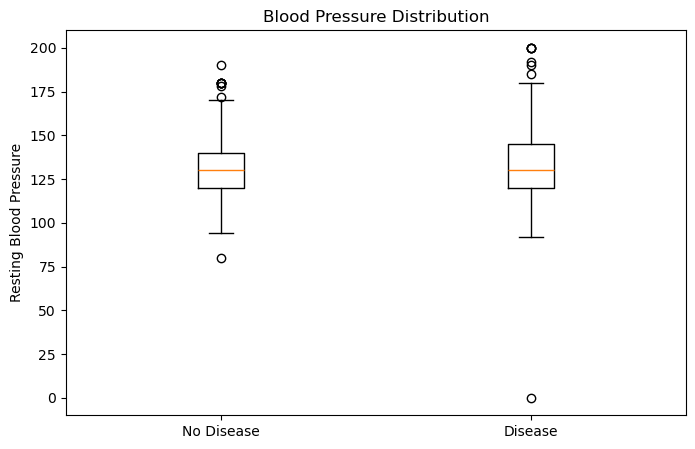

In [49]:
# visualization
plt.figure(figsize=(8,5))

plt.boxplot([
    heart_data[heart_data['heart_disease']==0]['trestbps'],
    heart_data[heart_data['heart_disease']==1]['trestbps']
])

plt.xticks(
    [1,2],
    ['No Disease','Disease']
)

plt.ylabel(
    "Resting Blood Pressure"
)

plt.title(
    "Blood Pressure Distribution"
)

plt.show()

Why boxplots?

Health data often contains outliers.

Boxplots show:

median
spread
extreme values

Blood pressure distributions showed variation across disease groups, suggesting a potential relationship between cardiovascular stress indicators and disease presence.

In [50]:
# Chest Pain Patterns
cp_map = {
1:'Typical Angina',
2:'Atypical Angina',
3:'Non-anginal',
4:'Asymptomatic'
}

heart_data['chest_pain']=heart_data['cp'].map(cp_map)

In [52]:
# analyze prevalence
cp_analysis=(
    pd.crosstab(
        heart_data['cp'],
        heart_data['heart_disease'],
        normalize='index'
    )
*100
)

print(cp_analysis)

heart_disease            0          1
cp                                   
asymptomatic     20.967742  79.032258
atypical angina  86.206897  13.793103
non-anginal      64.215686  35.784314
typical angina   56.521739  43.478261


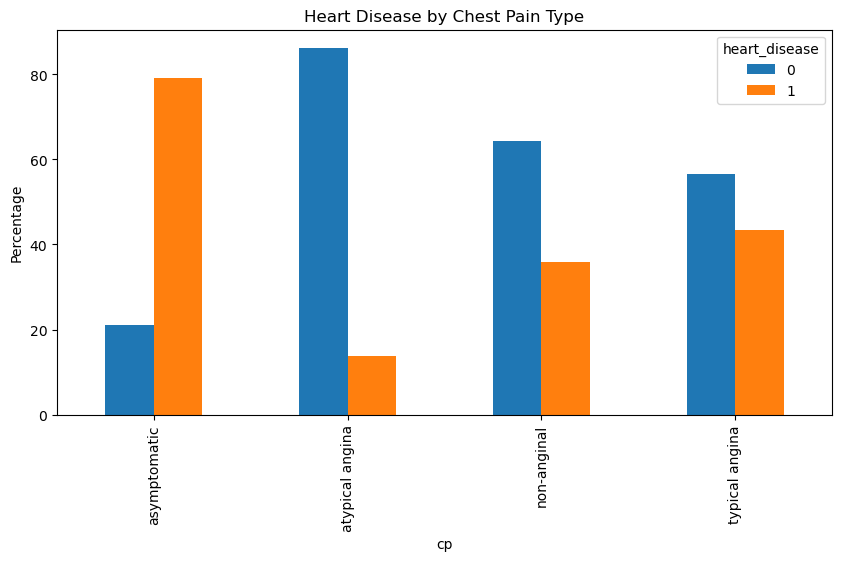

In [53]:
# visualization
cp_analysis.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel(
    "Percentage"
)

plt.title(
    "Heart Disease by Chest Pain Type"
)

plt.show()

Certain symptom categories demonstrated stronger disease concentration, highlighting symptom-driven screening opportunities.